<a href="https://colab.research.google.com/github/kidanuadalia-oss/DS2022/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is linear in its parameters/coefficients  not necessarily in the features themselves. That means the predicted output is a weighted sum of the inputs: ŷ = β₀ + β₁x₁ + β₂x₂ + ... You can have x² as a feature and it's still a linear model, because the coefficients are still linear.
2. It depends on how you handle the dummy variable trap. If you drop one category and keep the intercept, the intercept represents the mean of the dropped (reference) group, and each dummy coefficient is the difference in mean from that reference group. If you drop the intercept and keep all dummies, each coefficient is the mean of that group directly.
3. Technically yes, but it's a bad idea. Linear regression predicts continuous values, so nothing stops it from predicting probabilities below 0 or above 1, which makes no sense for a binary outcome. Logistic regression is the proper tool — it constrains predictions to [0,1] via the sigmoid function.
4. Training error is much lower than test/validation error and Model performance drops significantly on new data

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Q1_clean.csv to Q1_clean.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

df = pd.read_csv('Q1_clean.csv')
df.columns = df.columns.str.strip()
df = df.rename(columns={'Review Scores Rating': 'Score'})
df = df[['Price', 'Score', 'Neighbourhood']].dropna()

                Price  Score
Neighbourhood               
Manhattan      183.66  91.80
Staten Island  146.17  90.84
Brooklyn       127.75  92.36
Queens          96.86  91.55
Bronx           75.28  91.65

Most expensive: Manhattan


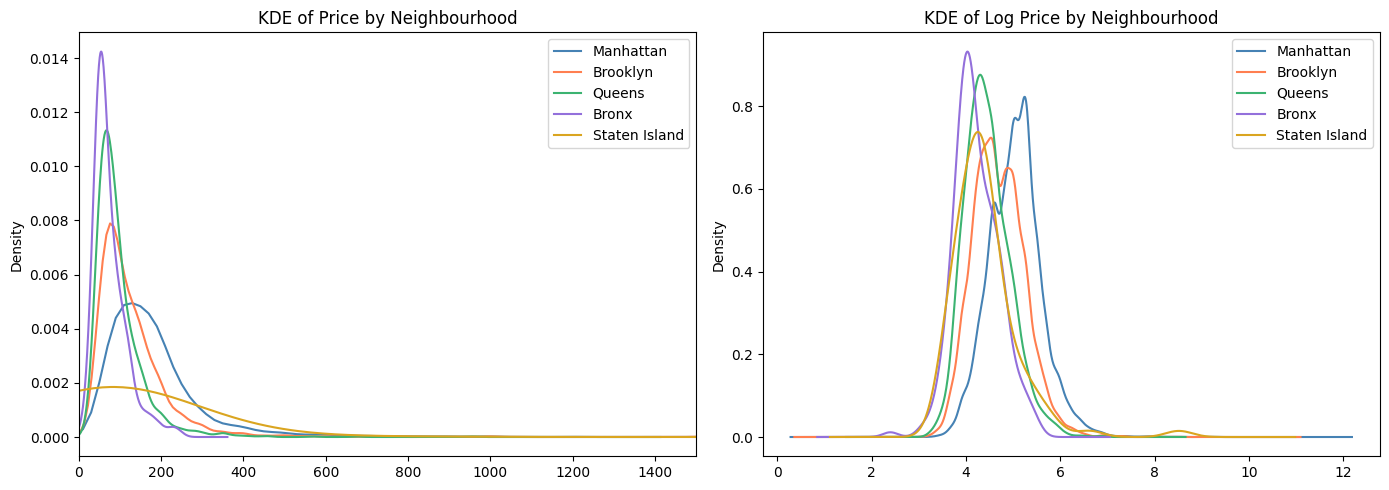

In [ ]:
group_stats = df.groupby('Neighbourhood')[['Price', 'Score']].mean().round(2)
print(group_stats.sort_values('Price', ascending=False))
print(f"\nMost expensive: {group_stats['Price'].idxmax()}")

neighbourhoods = df['Neighbourhood'].unique()
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, hood in enumerate(neighbourhoods):
    subset = df[df['Neighbourhood'] == hood]['Price']
    subset.plot.kde(ax=axes[0], label=hood, color=colors[i])
    np.log1p(subset).plot.kde(ax=axes[1], label=hood, color=colors[i])

axes[0].set_title('KDE of Price by Neighbourhood')
axes[0].set_xlim(0, 1500)
axes[0].legend()
axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=float)
X2 = sm.add_constant(dummies)
y = df['Price']
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

ref = [c for c in df['Neighbourhood'].unique() if c not in dummies.columns][0]
print(f"\nReference group: {ref}")
print(f"Intercept = mean price for {ref}: {df[df['Neighbourhood']==ref]['Price'].mean():.2f}")
print("\nEach coef = group mean minus reference group mean:")
for hood in dummies.columns:
    diff = group_stats.loc[hood,'Price'] - group_stats.loc[ref,'Price']
    print(f"  {hood}: coef={model2.params[hood]:.2f}, actual diff={diff:.2f}")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        19:50:11   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

The intercept is the mean price for the Bronx (reference). Each dummy coefficient is the difference in average nightly price relative to the Bronx. The coefficients perfectly match the raw group mean differences.


In [ ]:
X3 = sm.add_constant(df['Score'])
model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        19:50:14   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         60.8784     10.423      5.841      0.0

 A 1-point increase in Review Score Rating is associated with a $1.02 increase in nightly price, holding all else equal. However R² ≈ 0.004 — ratings alone explain almost none of the price variation.

In [ ]:
X4 = sm.add_constant(pd.concat([dummies, df['Score'].reset_index(drop=True)], axis=1))
X4.index = y.index
model4 = sm.OLS(y, X4).fit()
print(model4.summary())
print(f"\nScore slope: {model3.params['Score']:.4f} → {model4.params['Score']:.4f} after adding neighbourhood")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        19:50:17   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -23.8126     14.105     -1.688

The Score slope barely moves (1.02 → 1.08), meaning Score and Neighbourhood are not strongly correlated — they capture different things. The neighbourhood coefficients are also stable.

In [ ]:
df2 = df.copy().reset_index(drop=True)
df2 = pd.concat([df2, dummies.reset_index(drop=True)], axis=1)
for hood in dummies.columns:
    df2[f'{hood}_x_Score'] = df2[hood] * df2['Score']

int_cols = [c for c in df2.columns if '_x_Score' in c]
X5 = sm.add_constant(df2[list(dummies.columns) + ['Score'] + int_cols])
model5 = sm.OLS(df2['Price'], X5).fit()
print(model5.summary())

print(f"\n{ref} (reference): {model5.params['Score']:.4f}")
for hood in dummies.columns:
    total = model5.params['Score'] + model5.params[f'{hood}_x_Score']
    print(f"  {hood}: {total:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:50:19   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    22.63

Manhattan and Brooklyn have similar, positive Score slopes (~1.3). Queens and Bronx are flatter (~0.5). Staten Island is a wild outlier (very negative) likely due to few observations — don't read too much into it.


In [ ]:
def get_rmse(X_df, y_series, k=5):
    scores = cross_val_score(LinearRegression(),
                             X_df.values.astype(float),
                             y_series.values.astype(float),
                             cv=k, scoring='neg_mean_squared_error')
    return np.sqrt(-scores.mean())

df_cv = df.copy().reset_index(drop=True)
dum_cv = pd.get_dummies(df_cv['Neighbourhood'], drop_first=True, dtype=float)
y_cv = df_cv['Price']

X3_cv = pd.concat([pd.DataFrame({'const':1}, index=df_cv.index), df_cv[['Score']]], axis=1)
X4_cv = pd.concat([pd.DataFrame({'const':1}, index=df_cv.index), dum_cv, df_cv[['Score']]], axis=1)

df_cv2 = pd.concat([df_cv, dum_cv], axis=1)
for hood in dum_cv.columns:
    df_cv2[f'{hood}_x_Score'] = df_cv2[hood] * df_cv2['Score']
int_cols = [c for c in df_cv2.columns if '_x_Score' in c]
X5_cv = pd.concat([pd.DataFrame({'const':1}, index=df_cv.index), dum_cv, df_cv[['Score']], df_cv2[int_cols]], axis=1)

print(f"Model Q2.3 (Score only):            RMSE = {get_rmse(X3_cv, y_cv):.2f}")
print(f"Model Q2.4 (Neighbourhood + Score): RMSE = {get_rmse(X4_cv, y_cv):.2f}")
print(f"Model Q2.5 (Neighbourhood * Score): RMSE = {get_rmse(X5_cv, y_cv):.2f}")

Model Q2.3 (Score only):            RMSE = 148.67
Model Q2.4 (Neighbourhood + Score): RMSE = 145.30
Model Q2.5 (Neighbourhood * Score): RMSE = 146.35


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [ ]:
import urllib.request, zipfile, os

def download_data(force=False):
    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir

download_data()

Download complete
Extracting data files...
Data extracted


'./data'

In [ ]:
df3 = pd.read_csv('./data/cars_hw.csv')

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count       mean       std       min       25%        50%  \
Body_Type                                                              
crossover   21.0   705095.0   72850.0  608000.0  638000.0   706000.0   
hatchback  484.0   533977.0  173087.0  188000.0  401750.0   509000.0   
muv         38.0   626421.0  184093.0  328000.0  489750.0   621500.0   
sedan      227.0   809784.0  286737.0  368000.0  598000.0   772000.0   
suv        206.0  1176495.0  417479.0  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


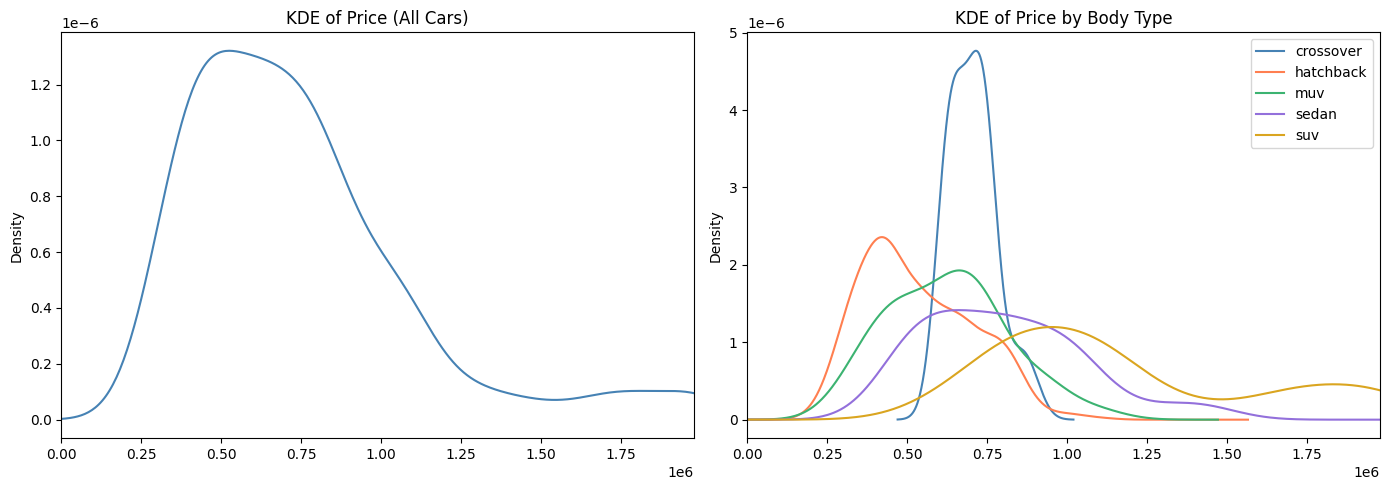

In [ ]:
df3 = pd.read_csv('./data/cars_hw.csv')
df3 = df3[['Price', 'Seating_Capacity', 'Body_Type', 'Make_Year']].dropna()

print(df3['Price'].describe())
print(df3.groupby('Body_Type')['Price'].describe().round(0))

body_types = sorted(df3['Body_Type'].unique())
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df3['Price'].plot.kde(ax=axes[0], color='steelblue')
axes[0].set_title('KDE of Price (All Cars)')
axes[0].set_xlim(0, df3['Price'].quantile(0.99))

for i, bt in enumerate(body_types):
    df3[df3['Body_Type']==bt]['Price'].plot.kde(ax=axes[1], label=bt, color=colors[i])
axes[1].set_title('KDE of Price by Body Type')
axes[1].set_xlim(0, df3['Price'].quantile(0.99))
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
X_cont = sm.add_constant(df3['Seating_Capacity'])
model_cont = sm.OLS(df3['Price'], X_cont).fit()
print(model_cont.summary())
print(f"Slope: {model_cont.params['Seating_Capacity']:,.0f} INR per additional seat")

seat_dum = pd.get_dummies(df3['Seating_Capacity'].astype(str), drop_first=True, dtype=float)
model_cat = sm.OLS(df3['Price'], sm.add_constant(seat_dum)).fit()
print(model_cat.summary())

print(df3.groupby('Seating_Capacity')['Price'].mean().sort_index().round(0))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        20:02:56   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

Degree  1: CV RMSE = 316,694
Degree  2: CV RMSE = 317,513
Degree  3: CV RMSE = 316,828
Degree  4: CV RMSE = 316,977
Degree  5: CV RMSE = 316,435
Degree  6: CV RMSE = 316,777
Degree  7: CV RMSE = 315,926
Degree  8: CV RMSE = 315,199
Degree  9: CV RMSE = 315,657
Degree 10: CV RMSE = 316,067

Optimal degree: 8


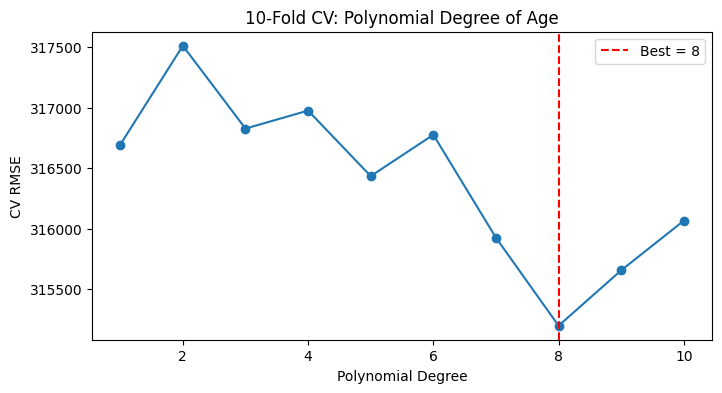

In [ ]:
df3['Age'] = 2024 - df3['Make_Year']

degrees = range(1, 11)
cv_scores = []

for d in degrees:
    X_poly = sm.add_constant(pd.DataFrame({f'Age^{i}': df3['Age']**i for i in range(1, d+1)}))
    rmse = np.sqrt(-cross_val_score(LinearRegression(),
                                    X_poly.values.astype(float),
                                    df3['Price'].values.astype(float),
                                    cv=10,
                                    scoring='neg_mean_squared_error').mean())
    cv_scores.append(rmse)
    print(f"Degree {d:2d}: CV RMSE = {rmse:,.0f}")

best_d = list(degrees)[np.argmin(cv_scores)]
print(f"\nOptimal degree: {best_d}")

plt.figure(figsize=(8,4))
plt.plot(list(degrees), cv_scores, marker='o')
plt.axvline(best_d, color='red', linestyle='--', label=f'Best = {best_d}')
plt.xlabel('Polynomial Degree')
plt.ylabel('CV RMSE')
plt.title('10-Fold CV: Polynomial Degree of Age')
plt.legend()
plt.show()

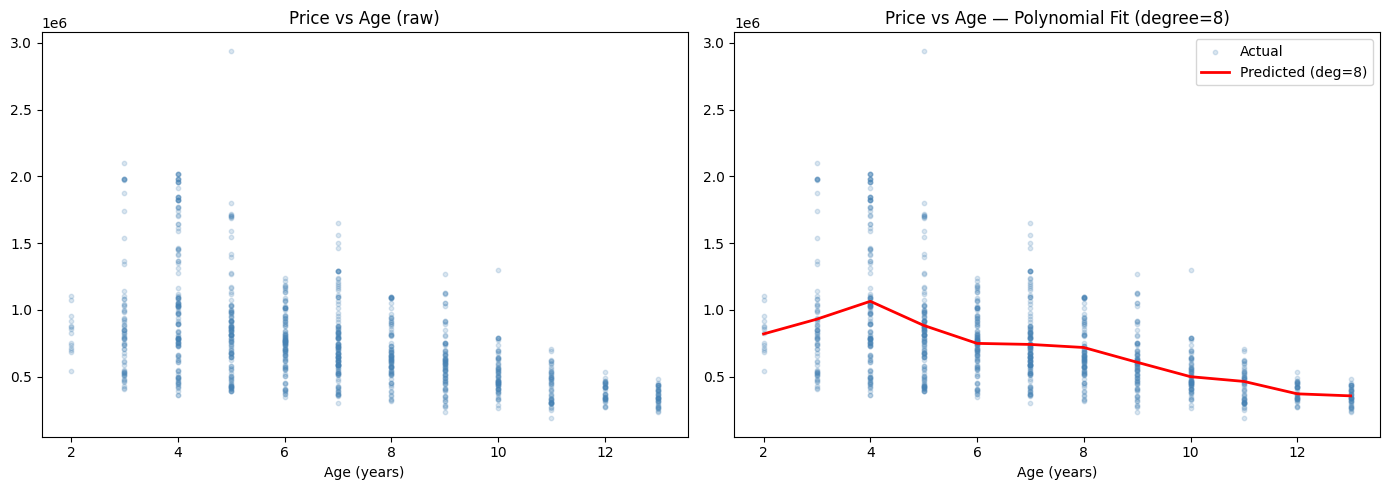

In [ ]:
X_best = sm.add_constant(pd.DataFrame({f'Age^{i}': df3['Age']**i for i in range(1, best_d+1)}))
model_best = sm.OLS(df3['Price'], X_best).fit()
df3['Predicted'] = model_best.fittedvalues
df3_s = df3.sort_values('Age')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df3['Age'], df3['Price'], alpha=0.2, s=10, color='steelblue')
axes[0].set_title('Price vs Age (raw)')
axes[0].set_xlabel('Age (years)')

axes[1].scatter(df3['Age'], df3['Price'], alpha=0.2, s=10, color='steelblue', label='Actual')
axes[1].plot(df3_s['Age'], df3_s['Predicted'], color='red', linewidth=2, label=f'Predicted (deg={best_d})')
axes[1].set_title(f'Price vs Age — Polynomial Fit (degree={best_d})')
axes[1].set_xlabel('Age (years)')
axes[1].legend()
plt.tight_layout()
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [ ]:
df4 = pd.read_csv('./data/heart_hw.csv')
print(df4.head())
print(df4.dtypes)

props = df4.groupby('transplant')['y'].mean()
print(f"\nControl survival rate:   {props['control']:.4f}")
print(f"Treatment survival rate: {props['treatment']:.4f}")
ATE = props['treatment'] - props['control']
print(f"ATE: {ATE:.4f}")

The ATE is the raw difference in 3-year survival rates between transplant recipients and the control group.

In [ ]:
df4['treated'] = (df4['transplant'] == 'treatment').astype(float)

X42 = sm.add_constant(df4['treated'])
model42 = sm.OLS(df4['y'], X42).fit()
print(model42.summary())

print(f"\nIntercept = control survival rate: {props['control']:.4f}")
print(f"Transplant coef = ATE: {ATE:.4f}")

The intercept equals the control group's survival rate, and the transplant coefficient exactly equals the ATE, linear regression with a single dummy just recovers the group means.

In [ ]:
X43 = sm.add_constant(df4[['treated', 'age']])
model43 = sm.OLS(df4['y'], X43).fit()
print(model43.summary())

print(f"\nTransplant coef without age: {model42.params['treated']:.4f}")
print(f"Transplant coef with age:    {model43.params['treated']:.4f}")

age_range = np.linspace(df4['age'].min(), df4['age'].max(), 200)

pred_control   = model43.params['const'] + model43.params['age'] * age_range
pred_treatment = model43.params['const'] + model43.params['treated'] + model43.params['age'] * age_range

plt.figure(figsize=(9, 5))
plt.plot(age_range, pred_control,   label='Control',   color='steelblue')
plt.plot(age_range, pred_treatment, label='Treatment', color='coral')
plt.axhline(ATE, color='black', linestyle='--', label=f'Raw ATE = {ATE:.3f}')
plt.xlabel('Age')
plt.ylabel('Predicted P(survive 3 years)')
plt.title('Predicted Survival by Age (controlling for age)')
plt.legend()
plt.tight_layout()
plt.show()

The intercept is the predicted survival probability for a control patient at age zero, which is not meaningful on its own but serves as the model's baseline. The age coefficient shows how survival changes per additional year of age. The transplant coefficient is the average treatment effect after controlling for age. If it shifts from the earlier model, it means age and transplant assignment were correlated, likely because older or sicker patients were being prioritized for transplants.

In [ ]:
df4['treated_x_age'] = df4['treated'] * df4['age']

X44 = sm.add_constant(df4[['treated', 'age', 'treated_x_age']])
model44 = sm.OLS(df4['y'], X44).fit()
print(model44.summary())

# Plot predicted survival by age for each group
pred_control2   = model44.params['const'] + model44.params['age'] * age_range
pred_treatment2 = (model44.params['const'] + model44.params['treated']
                   + (model44.params['age'] + model44.params['treated_x_age']) * age_range)

plt.figure(figsize=(9, 5))
plt.plot(age_range, pred_control2,   label='Control',   color='steelblue')
plt.plot(age_range, pred_treatment2, label='Treatment', color='coral')
plt.axhline(ATE, color='black', linestyle='--', label=f'Raw ATE = {ATE:.3f}')
plt.xlabel('Age')
plt.ylabel('Predicted P(survive 3 years)')
plt.title('Predicted Survival by Age (with interaction)')
plt.legend()
plt.tight_layout()
plt.show()


The interaction term allows the benefit of a transplant to vary depending on a patient's age. If the interaction coefficient is negative, it means younger patients tend to benefit more from receiving a transplant than older patients do. Visually, this shows up as the treatment line having a steeper downward slope compared to the control line. Because the two lines are not parallel, they will eventually cross at some age threshold. Before that crossing point, transplants are associated with improved survival. After it, the model suggests transplants may offer little benefit or could even be associated with worse outcomes.


In [ ]:
from sklearn.metrics import mean_squared_error

def cv_rmse(X_df, y_series, k=10):
    scores = cross_val_score(LinearRegression(),
                             X_df.values.astype(float),
                             y_series.values.astype(float),
                             cv=k, scoring='neg_mean_squared_error')
    return np.sqrt(-scores.mean())

y4 = df4['y']

X_m2 = sm.add_constant(df4[['treated']])
X_m3 = sm.add_constant(df4[['treated', 'age']])
X_m4 = sm.add_constant(df4[['treated', 'age', 'treated_x_age']])

print(f"Model Q4.2 (transplant only):          RMSE = {cv_rmse(X_m2, y4):.4f}")
print(f"Model Q4.3 (transplant + age):         RMSE = {cv_rmse(X_m3, y4):.4f}")
print(f"Model Q4.4 (transplant * age):         RMSE = {cv_rmse(X_m4, y4):.4f}")


Using this model to prioritize transplant access raises several concerns. To start, the model is a linear probability model, which means it can predict survival probabilities below 0 or above 1. That makes it fundamentally unreliable for individual-level decisions. On top of that, age is used as a predictor, which introduces real fairness concerns. Systematically deprioritizing older patients based on statistical outputs could constitute age discrimination, regardless of how the model was intended to function.
There is also the issue of selection bias in the underlying data. Patients who were selected for transplants in the past likely differed in unobserved ways from those who were not, whether in illness severity, social support, or other factors that never made it into the dataset. That means the model's estimated "treatment effect" is not truly causal; it reflects patterns in who was chosen, not necessarily who would benefit most